In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle
import glob
import urllib.request
from urllib.error import URLError, HTTPError
from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
import swan_functions as swanfuns
import run_funs as runfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


<class 'netCDF4.Variable'>
float64 ocean_time(ocean_time)
    long_name: time since initialization
    units: seconds since 1999-01-01 00:00:00
    calendar: proleptic_gregorian
    field: time, scalar, series
unlimited dimensions: ocean_time
current shape = (4,)
filling on, default _FillValue of 9.969209968386869e+36 used
[datetime.datetime(2025, 3, 13, 6, 0)
 datetime.datetime(2025, 3, 13, 12, 0)
 datetime.datetime(2025, 3, 13, 18, 0)
 datetime.datetime(2025, 3, 13, 18, 50, 36)]
2025-03-13 18:50:36


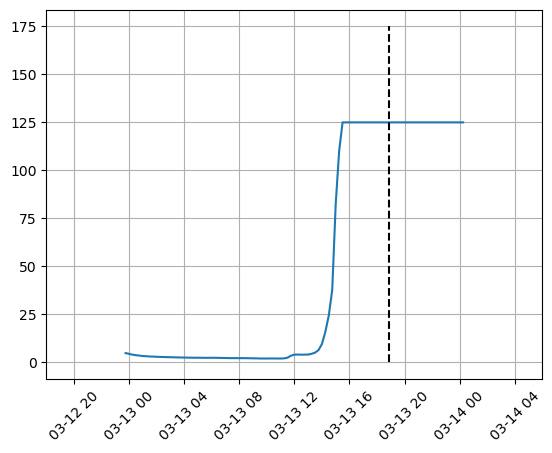

In [3]:
fn = '/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202503130000_202503140000.nc'
t0 = datetime(1999,1,1)
with nc.Dataset(fn) as ds:
    #print(ds)
    print(ds.variables['ocean_time'])
    tsec = ds.variables['ocean_time'][:].data
    t_dt = t0 + tsec * timedelta(seconds=1)
    print(t_dt)
    t_blow = t_dt[-1]

print(t_blow)
#fn = '/dataSIO/PHM_Simulations/riv_ibwc_raw/river_ncs/river_20250313_20250314.nc'
fn = '/scratch/PHM_Simulations/riv_ibwc_raw/LV4_Forecast/Forc/river_20250313_20250314.nc'

with nc.Dataset(fn) as ds:
    t = ds.variables['river_time'][:].data
    Q = 5*ds.variables['river_transport'][:,0].data

t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(days=1)
fig, ax = plt.subplots()
ax.plot(t_dt,-Q)
ax.plot([t_blow,t_blow],[0,175],'--k')
t1 = datetime(2025,3,12,18,0,0)
t2 = datetime(2025,3,14,6,0,0)
plt.xlim(t1,t2)
plt.xticks(rotation=45)
plt.grid(True)

In [ ]:
from scipy.special import erf

def my_exp_filter(q_i):


    dtt=15.0
    ii = np.arange(-1.5*24*60,1.5*24*60 + dtt,dtt)  # 3 full days at 15 min sampling

#    ii = np.arange(-(nF-1)/2,(nF+1)/2)
    nF = len(ii)
    print('the length of the filter is:')
    print(nF)
    i0 = np.argwhere(ii>0)
    nt = len(q_i)
    Q3 = np.zeros(np.shape(q_i))
    TT = np.zeros(np.shape(q_i))
    for a in np.arange(nt):
        if a<(nF-1)/2:
            iq = np.arange( (nF+1)/2 + a )
            iif = np.arange( (nF-1)/2-a,nF)
            #print(a,iq,iif)
        elif a > nt-(nF-1)/2-1:
            iq = np.arange( nt-(nF-1)/2 - (nt-a) ,nt)
            iif = np.arange( 0, nF - a + (nt - (nF-1)/2) - 1 )
            #print(a,iq,iif)
        else:
            iq = np.arange( a - (nF-1)/2, a + (nF+1)/2 )
            iif = np.arange( 0 , nF)
            #print(a,iq,iif)
        
        q0 = q_i[a]
        delta=0.01
        #tau = (erf((q0-150)/20) + 1 + delta) / (2 + delta) / 2.0 # tau in days, need in minutes...
        #
        Qcut = 150 # above which  tau = 0.5
        tau = q0 / (2*Qcut)
        if tau>0.5:
            tau=0.5
        elif tau<0.01:
            tau=0.01

        tau = tau * 24 * 60
        #tau = (erf((q0-150)/20) + 1)
        TT[a] = tau

        F = np.exp( ii  / tau)
        F[i0] = 0
        F2 = F[iif.astype(int)]
        F2 = F2 / np.sum(F2)
        Q2 = q_i[iq.astype(int)]
        Q3[a] = np.sum(F2*Q2)
    
    return Q3, TT



In [2]:
def make_flat_q(qi,qcut):
    # this flattens a time series of qi so that values don't excede qcut
    # it redistributes the flow to later times
    ib = np.argwhere(qi>qcut)
    # need to remove ib if it equals len(qi)
    i_last = np.argwhere( ib == len(qi)-1 )
    if len(i_last)>0:
        ib = np.delete(ib,i_last)
    
    # main loop to move q to later times...
    while len(ib)>0:
        dq = qi-qcut
        q2 = qi.copy()
        q2[ib] = qcut
        q2[ib+1] = q2[ib+1] + dq[ib]
        ib = np.argwhere(q2>qcut)

        if len(ib) > 0:
            i_last = np.argwhere( ib == len(qi)-1 )
            # remove last index.
            if len(i_last)>0:
                ib = np.delete(ib,i_last)
                # hook in case piles up at the end...
                q2[-1]=qcut
                if len(ib) == 1:
                    ib = []
 
        qi = q2

    return qi


In [2]:
fn_ibwc = '/dataSIO/PHM_Simulations/riv_ibwc_raw/river_ncs/river_20250101_20250102.nc'
fn_vpfm = '/dataSIO/PHM_Simulations/riv_nwm/river_ncs/river_20250101_20250102.nc'
fn_nwm  = '/dataSIO/PHM_Simulations/riv_vpfm/river_ncs/river_20250101_20250102.nc'

date1 = ['20250101','20250102']
date2 = ['20250102','20250103']
types = ['ibwc_raw','nwm','vpfm']

-2.10320251533132 -1.7796577320987617
-0.3899999912828207 -0.36999999172985554
-0.8554504860095807 -0.8554504860095807
-0.8443717882591535 -2.5499068187130733
-0.37249999167397624 -0.36999999172985554
-0.9308984997934983 -0.9308984997934983


(array([20089.  , 20089.25, 20089.5 , 20089.75, 20090.  , 20090.25,
        20090.5 , 20090.75, 20091.  ]),
 [Text(20089.0, 0, '01-01 00'),
  Text(20089.25, 0, '01-01 06'),
  Text(20089.5, 0, '01-01 12'),
  Text(20089.75, 0, '01-01 18'),
  Text(20090.0, 0, '01-02 00'),
  Text(20090.25, 0, '01-02 06'),
  Text(20090.5, 0, '01-02 12'),
  Text(20090.75, 0, '01-02 18'),
  Text(20091.0, 0, '01-03 00')])

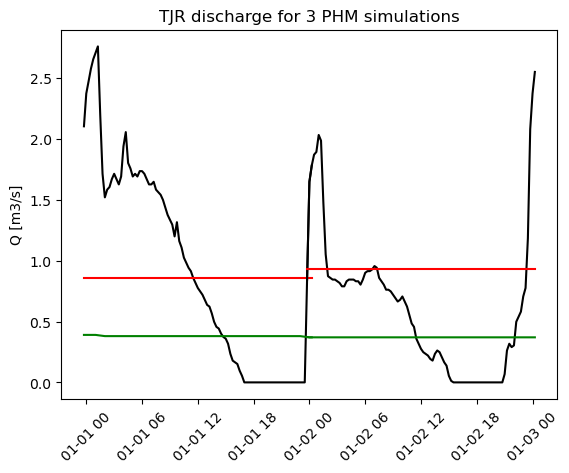

In [9]:
fig, ax = plt.subplots()

cnt = 0
clrs = ['k','g','r']
for date in date1:
    cntc = 0
    for type in types:
        fn = '/dataSIO/PHM_Simulations/riv_' + type + '/river_ncs/river_' + date + '_' + date2[cnt] + '.nc'

        with nc.Dataset(fn) as ds:
            t = ds.variables['river_time'][:].data
            Q = 5*ds.variables['river_transport'][:,0].data
            print(Q[0],Q[-1])

        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(days=1)
        ax.plot(t_dt, -Q ,label = fn, color = clrs[cntc])
        cntc=cntc+1

    cnt = cnt+1

# Add the title
plt.title("TJR discharge for 3 PHM simulations")
# Add the y-axis label
plt.ylabel("Q [m3/s]")
# Rotate x-tick labels by 45 degrees
plt.xticks(rotation=45)


['TJR' 'Otay' 'SW']
0.3899999912828207 0.3799999915063381
9497.0 9497.958333333334
['TJR' 'Otay' 'SW']
0.36999999172985554 0.36999999172985554
9498.0 9498.958333333334
['TJR' 'Otay' 'SW']
0.36999999172985554 0.3899999912828207
9499.0 9499.958333333334


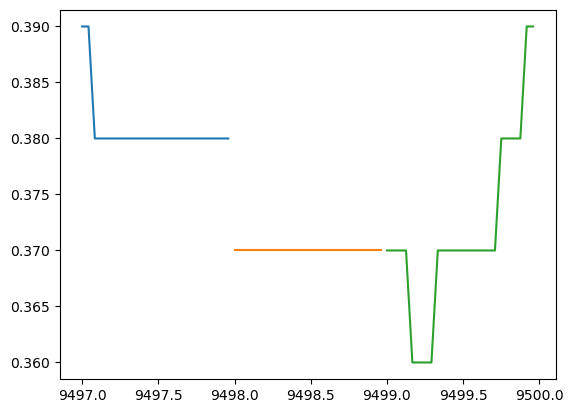

In [4]:
fig, ax = plt.subplots()
fn_nwm1 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250101.nc'
fn_nwm2 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250102.nc'
fn_nwm3 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250103.nc'
for fn in [fn_nwm1,fn_nwm2,fn_nwm3]:    
    with nc.Dataset(fn) as ds:
        print(ds.variables['station_id'][:])
        t = ds.variables['time'][:].data
        Q = ds.variables['discharge'][:,0].data
        print(Q[0],Q[-1])
        print(t[0],t[-1])

    ax.plot(t, Q)


[0.38999999 0.38999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.35999999 0.35999999
 0.35999999 0.35999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.38999999 0.38999999]


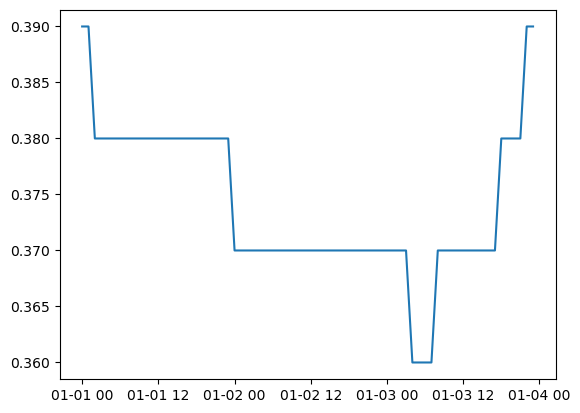

In [5]:
fnames = [fn_nwm1,fn_nwm2,fn_nwm3]
t_nc, q_nc, rid_nc = riverfuns.get_data_from_nwm_nc_files(fnames)

fig, ax = plt.subplots()
ax.plot(t_nc, q_nc[:,0])

print(q_nc[:,0])


In [ ]:
t0 = datetime(2025,1,1,0,0,0)
nday  = 1   
t2 = t0 + nday * timedelta(days=1)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0-dt_riv,t2+2*dt_riv,dt_riv)
info_pkl="/scratch/PHM_Simulations/phm_vpfm.pkl"

q_sw, q_om, q_tjnwm = riverfuns.get_nwm_analysis_flow(t_riv,info_pkl)
print(q_tjnwm)



/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241231.nc  exists. No need to download.
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250101.nc  exists. No need to download.
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250102.nc  exists. No need to download.
need to get the data from the nc files...
[0.38999999 0.38999999 0.38999999 0.38999999 0.38999999 0.38999999
 0.38749999 0.38499999 0.38249999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999

In [3]:
fn_qtj_obs = '/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv'
t_tj_raw, q_tj_raw = riverfuns.get_all_tj_observed_data(fn_qtj_obs)
t_original = (t_tj_raw.astype('datetime64[ns]')).astype('int64')

t0 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,9,1,0,0,0)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0,t2+dt_riv,dt_riv)

t_i = (t_riv.astype('datetime64[ns]')).astype('int64')
q_tj_i = np.interp(t_i, t_original, q_tj_raw)

print(np.shape(t_i))
print(np.shape(t_original))
print(np.shape(q_tj_i))



(23329,)
(198428,)
(23329,)


In [32]:
def get_daily_max_Q(t_tj,Q_tj):
    
    t1 = datetime(2025,1,1,0,0)
    t2 = datetime(2025,8,31,0,0,0)


    t_daily = []
    q_max = []
    while t1 <= t2:
        t1_64 = np.datetime64(t1,'ns')
        msk = (t_tj>=t1_64) & (t_tj<t1_64+np.timedelta64(1, 'D'))
        iday = np.argwhere( msk )
        q_max.append( np.max( Q_tj[iday]))
        t_daily.append( t1 )
        t1 = t1 + timedelta(days=1)

    q_max = np.array( q_max )
    t_daily = np.array( t_daily )
    return t_daily, q_max

[[26]
 [44]
 [71]
 [72]]
[[ 89.76317595]
 [150.        ]
 [150.        ]
 [150.        ]]
[[datetime.datetime(2025, 1, 27, 0, 0)]
 [datetime.datetime(2025, 2, 14, 0, 0)]
 [datetime.datetime(2025, 3, 13, 0, 0)]
 [datetime.datetime(2025, 3, 14, 0, 0)]]
36922.2035518449
36898.302868569546
36918.3615974443
36922.2035518449
Number of NaNs in q_tj_i: 0
Number of NaNs in Q3: 0


(0.0, 20.0)

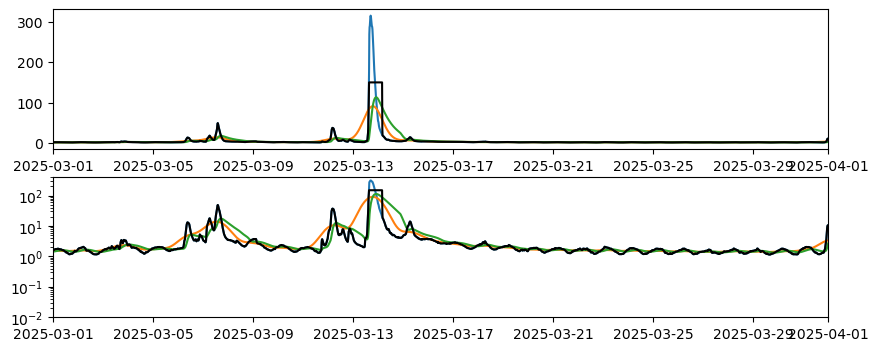

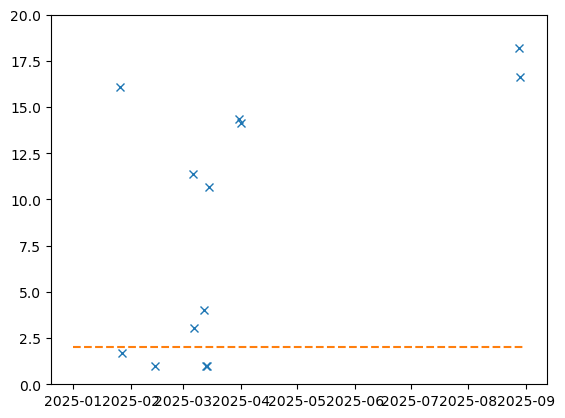

In [33]:

dtt=15.0
TF=.5*24*60
ii = np.arange(-2.5*TF,2.5*TF + dtt,dtt)  # in minutes!
Fg =  np.exp( - np.square(ii) / np.square(TF) )
Fg = Fg / np.sum(Fg)
Qg = np.convolve(q_tj_i,Fg,mode='same')
Fe = np.exp( - ii / TF )
ib = np.argwhere((Fe>1))
Fe[ib] = 0
Fe = Fe / np.sum(Fe)
Qe = np.convolve(q_tj_i,Fe,mode='same')
Qmax = 200
alpha =  q_tj_i / Qmax 
i1 = np.argwhere( alpha > 1)

Q3 = make_flat_q(q_tj_i,150)


t_i2 = t_i.astype('datetime64[ns]') 

tmx, qmax = get_daily_max_Q(t_i2,Q3)
dt_lv4 = 150.0 / qmax

i_sm = np.argwhere( (dt_lv4 < 2.0) )
print(i_sm)
print(qmax[i_sm])
print(tmx[i_sm])


fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))
ax1.plot(t_i2,q_tj_i)
ax1.plot(t_i2,Qg)
ax1.plot(t_i2,Qe)
ax1.plot(t_i2,Q3,'k')

t1 = datetime(2025,3,1)
t2 = datetime(2025,4,1)
ax1.set_xlim(t1,t2)

ax2.semilogy(t_i2,q_tj_i)
ax2.semilogy(t_i2,Qg)
ax2.semilogy(t_i2,Qe)
ax2.semilogy(t_i2,Q3,'k')
ax2.set_xlim(t1,t2)
ax2.set_ylim(1/100,400)

print(np.sum(q_tj_i))
print(np.sum(Qg))
print(np.sum(Qe))
print(np.sum(Q3))

nan_count = np.count_nonzero(np.isnan(q_tj_i))
print(f"Number of NaNs in q_tj_i: {nan_count}")
nan_count = np.count_nonzero(np.isnan(Q3))
print(f"Number of NaNs in Q3: {nan_count}")


fig, ax = plt.subplots()
ax.plot(tmx,dt_lv4,'x',linewidth=.5)
ax.plot(tmx,2*dt_lv4 / dt_lv4, '--')
ax.set_ylim(0,20)



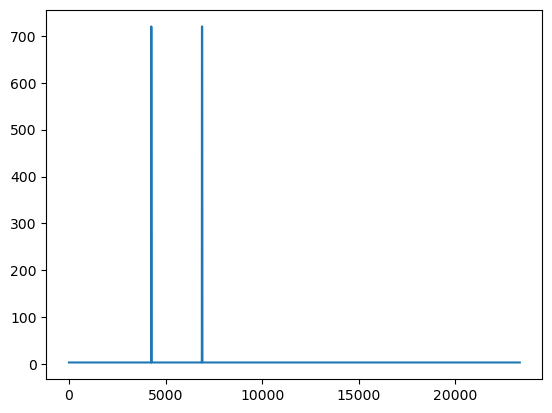

(np.float64(20089.0), np.float64(20332.0))

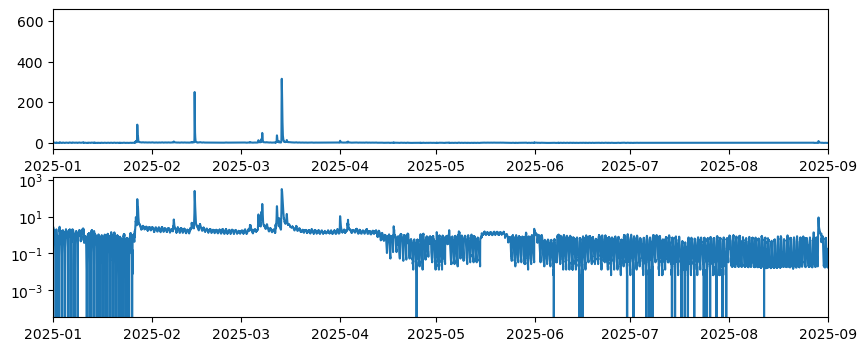

In [ ]:

fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))
ax1.plot(t_tj_raw,q_tj_raw)
t1 = datetime(2025,1,1)
t2 = datetime(2025,9,1)
ax1.set_xlim(t1,t2)
ax2.semilogy(t_tj_raw,q_tj_raw)
ax2.set_xlim(t1,t2)

#ax2.set_xticks(rotation=45)


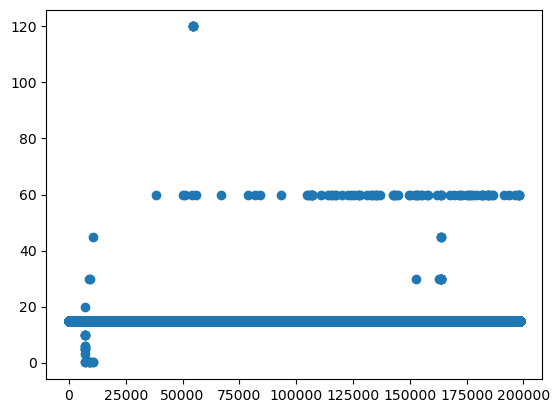

In [19]:
dt = []
for cnt in np.arange(len(t_tj_raw)-1):
    dt1 = t_tj_raw[cnt+1] - t_tj_raw[cnt]
    dt.append(dt1.total_seconds() / 60.0 )

fig, ax = plt.subplots()
ax.plot(dt,'o')



In [13]:
sim_start_time = '2025012100'
if (sim_start_time == '2025010100') or (sim_start_time == '2025012100'):
    print('in here')
else:
    print('not!')


in here


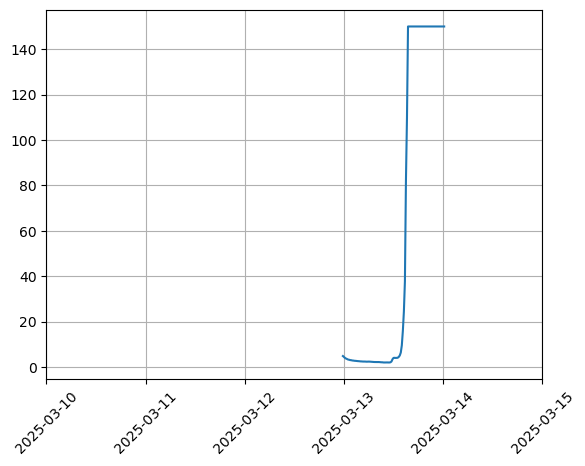

(array([20179., 20193., 20209., 20223., 20240.]),
 [Text(20179.0, 0, '2025-04-01'),
  Text(20193.0, 0, '2025-04-15'),
  Text(20209.0, 0, '2025-05-01'),
  Text(20223.0, 0, '2025-05-15'),
  Text(20240.0, 0, '2025-06-01')])

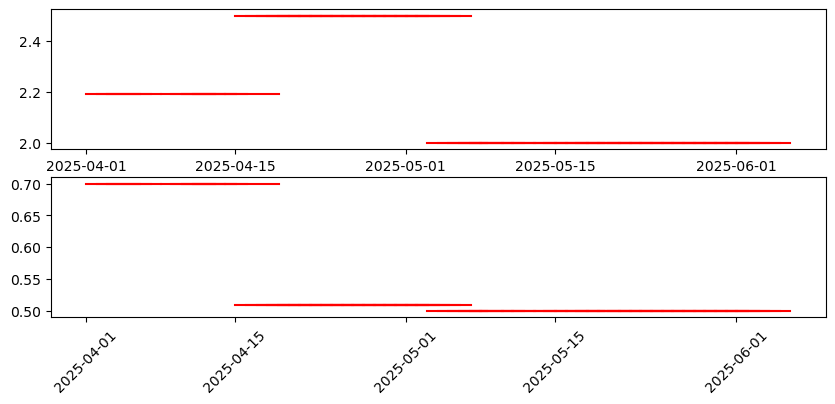

In [ ]:
t1 = '2025040100'
t2 = '2025060100'
dir0 = '/dataSIO/PFM_Simulations/Archive/Forcing/'
t0 = datetime.strptime(t1,'%Y%m%d%H')
tend = datetime.strptime(t2,'%Y%m%d%H')
fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))

while t0 <= tend:
    t_str = t0.strftime('%Y%m%d%H')
    f_name = dir0 + 'river_LV4_' + t_str + '.nc'
    if os.path.exists(f_name):
        with nc.Dataset(f_name) as ds:
            t = ds.variables['river_time'][:].data
            t_dt = datetime(1999,1,1,0,0,0) + t * timedelta(days=1)
            Q_tj = -5*ds.variables['river_transport'][:,0].data
            Q_pb = -ds.variables['river_transport'][:,5].data
            dye_pb = ds.variables['river_dye_01'][:,0,5].data
            dye_tj = ds.variables['river_dye_02'][:,0,0].data
            #ax1.plot(t_dt,Q_tj,'k')
            ax1.plot(t_dt,Q_pb,'r')
            #ax2.plot(t_dt,dye_tj,'k')
            ax2.plot(t_dt,dye_pb,'r')
            
            
         
    t0 = t0 + timedelta(days=1)

plt.xticks(rotation=45)





In [113]:
from scipy.special import erf

def my_exp_filter(q_i):

    dtt=15.0
    ii = np.arange(-1.25*24*60,1.25*24*60 + dtt,dtt)  # 2.5 full days at 15 min sampling

#    ii = np.arange(-(nF-1)/2,(nF+1)/2)
    nF = len(ii)
    print('the length of the filter is:')
    print(nF)
    i0 = np.argwhere(ii>0)
    nt = len(q_i)
    Q3 = np.zeros(np.shape(q_i))
    for a in np.arange(nt):
        if a<(nF-1)/2:
            iq = np.arange( (nF+1)/2 + a )
            iif = np.arange( (nF-1)/2-a,nF)
            #print(a,iq,iif)
        elif a > nt-(nF-1)/2-1:
            iq = np.arange( nt-(nF-1)/2 - (nt-a) ,nt)
            iif = np.arange( 0, nF - a + (nt - (nF-1)/2) - 1 )
            #print(a,iq,iif)
        else:
            iq = np.arange( a - (nF-1)/2, a + (nF+1)/2 )
            iif = np.arange( 0 , nF)
            #print(a,iq,iif)
        
        q0 = q_i[0]
        tau = .25* (erf((q0-150)/20) + 1) # tau in days, need in minutes...
        tau = tau * 24 * 60
        #tau = (erf((q0-150)/20) + 1)


        F = np.exp( ii  / tau)
        F[i0] = 0
        F2 = F[iif.astype(int)]
        F2 = F2 / np.sum(F2)
        Q2 = q_i[iq.astype(int)]
        Q3[a] = np.sum(F2*Q2)
    
    return Q3


In [154]:
q_i = np.array([0,120,0,0,0,120,170,190,180,150,100,0,0,0,0,160])
q2 = make_flat_q(q_i,150)

print(q_i)
print(q2)
print(np.sum(q_i))
print(np.sum(q2))



[  0 120   0   0   0 120 170 190 180 150 100   0   0   0   0 160]
[  0 120   0   0   0 120 150 150 150 150 150  40   0   0   0 150]
1190
1180


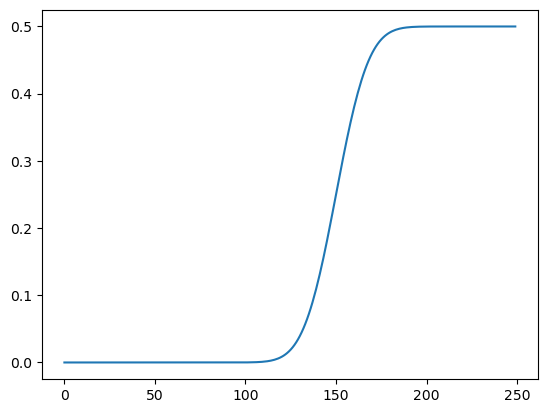

In [105]:
from scipy.special import erf


qq = np.arange(0,250)
tau = .25* (erf((qq-150)/20) + 1)
fig, ax = plt.subplots()
ax.plot(qq,tau)

